# 07. Lorenz-63 Ensemble Kalman Filter (Stochastic EnKF)

이 노트북에서는 Lorenz-63 모델에 **앙상블 칼만 필터(Ensemble Kalman Filter, EnKF)** 를 적용한다.

02번 노트북의 3D-Var는 background error covariance $B$ 를 **시간에 대해 고정된 정적 행렬**로 두었다.
EnKF는 대신 여러 개의 모델 상태(앙상블)를 동시에 적분하고, 그 앙상블의 퍼짐(spread)으로부터
**그 순간의 흐름에 맞는(flow-dependent) 공분산 $P^f$** 를 추정한다.

이번 실습의 목표는 다음과 같다.

1. 02번에서 만든 truth, 관측, 3D-Var 결과를 그대로 불러온다.
2. 잘못된 초기조건 주변에 초기 앙상블을 생성한다.
3. forecast 단계에서 각 멤버를 Euler 방법으로 전진시킨다.
4. 관측 시점마다 perturbed-observation stochastic EnKF analysis를 수행한다.
5. EnKF 앙상블 평균을 free run, 3D-Var와 비교한다.
6. `x`만 관측하는 경우 흐름 의존 공분산이 비관측 변수로 정보를 전파하는지 확인한다.
7. 앙상블 크기와 inflation의 영향을 살펴본다.

이번 실습에서도 시간적분 방법으로는 Euler 방법만 사용한다.

## 1. 라이브러리 불러오기

이번 실습에서는 기존 source module에 더해, 이번에 새로 작성한 EnKF 모듈을 사용한다.

- `lorenz_da.models.lorenz63`
- `lorenz_da.numerics.euler`
- `lorenz_da.observations.operator`
- `lorenz_da.observations.synthetic`
- `lorenz_da.assimilation.three_dvar` (3D-Var와의 비교용)
- `lorenz_da.assimilation.enkf` (이번에 추가한 모듈)
- `lorenz_da.utils.diagnostics`

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import (
    euler_step,
    integrate_euler,
)
from lorenz_da.observations.operator import (
    identity_observation_operator,
    partial_observation_operator,
)
from lorenz_da.observations.synthetic import (
    make_observation_indices,
    generate_synthetic_observations,
)
from lorenz_da.assimilation.three_dvar import (
    analysis_3dvar,
)
from lorenz_da.assimilation.enkf import (
    initialize_ensemble,
    ensemble_mean,
    sample_covariance,
    multiplicative_inflation,
    stochastic_enkf_analysis,
)
from lorenz_da.utils.diagnostics import (
    rmse_time_series,
    mean_rmse,
)

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

02번과 동일하게, 노트북이 `notebooks/` 안에서 실행되든 프로젝트 루트에서 실행되든
경로가 맞도록 자동으로 설정한다.

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. 실험 설정

EnKF를 02번 3D-Var와 **공정하게 비교**하기 위해, 실험 설정을 02번과 똑같이 맞춘다.

- 시간간격 `dt = 0.005`, 전체 시간 `tmax = 30`
- 관측 간격 `obs_interval = 20` (즉 시간 0.1마다 관측)
- 관측오차 표준편차 `obs_std = 2.0`
- 난수 seed `42`
- background 초기조건 `x0^b = x0^true + [5, -5, 8]`

In [3]:
dt = 0.005
tmax = 30.0
nsteps = int(tmax / dt)

obs_interval = 20
obs_std = 2.0
seed = 42

var_names = ["x", "y", "z"]

## 4. Truth, 관측, 3D-Var 결과 불러오기

01번에서 만든 truth trajectory와 02번에서 만든 관측, free run, 3D-Var 결과를 불러온다.

만약 해당 파일이 없다면(예: 01, 02 노트북을 아직 실행하지 않은 경우),
같은 설정으로 즉석에서 다시 생성한다. 이렇게 하면 이 노트북만 단독으로 실행해도 동작한다.

In [4]:
# --- truth trajectory ---
truth_path = TRAJECTORY_DIR / "lorenz63_truth_euler_dt0005_tmax30.npy"
time_path = TRAJECTORY_DIR / "lorenz63_time_dt0005_tmax30.npy"

if truth_path.exists() and time_path.exists():
    truth = np.load(truth_path)
    time = np.load(time_path)
    print("기존 truth trajectory를 불러왔다.")
else:
    print("truth가 없어서 새로 생성한다.")
    x0_true = lorenz63_default_initial_condition()
    truth = integrate_euler(x0=x0_true, dt=dt, nsteps=nsteps, rhs_func=lorenz63_rhs)
    time = np.arange(nsteps + 1) * dt
    np.save(truth_path, truth)
    np.save(time_path, time)

# 관측 시점
obs_indices = make_observation_indices(nsteps=nsteps, obs_interval=obs_interval)
obs_times = time[obs_indices]
obs_index_set = set(int(i) for i in obs_indices)

# 관측 연산자와 관측오차 공분산 (모든 변수 관측)
H_all = identity_observation_operator(state_dim=3)
R_all = (obs_std**2) * np.eye(3)

# 잘못된 background 초기조건
x0_true = truth[0]
x0_background = x0_true + np.array([5.0, -5.0, 8.0])

print("truth shape:", truth.shape)
print("number of observation times:", len(obs_indices))

기존 truth trajectory를 불러왔다.
truth shape: (6001, 3)
number of observation times: 300


In [5]:
# --- 모든 변수 관측값 ---
obs_all_path = ASSIM_DIR / "02_observations_allvars.npy"
if obs_all_path.exists():
    observations_all = np.load(obs_all_path)
    print("02번의 관측값을 불러왔다.")
else:
    print("관측값이 없어서 새로 생성한다.")
    rng_obs = np.random.default_rng(seed)
    observations_all = generate_synthetic_observations(
        truth=truth, obs_indices=obs_indices, H=H_all, obs_std=obs_std, rng=rng_obs
    )


def run_free(x0):
    "관측을 사용하지 않는 free run (Euler 적분)."
    out = np.zeros_like(truth)
    out[0] = x0
    for n in range(nsteps):
        out[n + 1] = euler_step(out[n], dt, lorenz63_rhs)
    return out


def run_3dvar(x0, observations, H, B, R):
    "관측 시점마다 3D-Var analysis를 수행하는 DA run."
    out = np.zeros_like(truth)
    out[0] = x0
    counter = 0
    for n in range(nsteps):
        xb = euler_step(out[n], dt, lorenz63_rhs)
        if (n + 1) in obs_index_set:
            out[n + 1] = analysis_3dvar(
                xb=xb, y=observations[counter], H=H, B=B, R=R
            )
            counter += 1
        else:
            out[n + 1] = xb
    return out


# --- free run ---
free_run_path = ASSIM_DIR / "02_free_run_euler.npy"
if free_run_path.exists():
    free_run = np.load(free_run_path)
    print("02번의 free run을 불러왔다.")
else:
    free_run = run_free(x0_background)

# --- 3D-Var (모든 변수 관측, diagonal B) ---
dvar_all_path = ASSIM_DIR / "02_3dvar_allvars_euler.npy"
if dvar_all_path.exists():
    da_3dvar_all = np.load(dvar_all_path)
    print("02번의 3D-Var 결과를 불러왔다.")
else:
    B_diag = (4.0**2) * np.eye(3)
    da_3dvar_all = run_3dvar(x0_background, observations_all, H_all, B_diag, R_all)

print("free run mean RMSE :", mean_rmse(free_run, truth))
print("3D-Var  mean RMSE :", mean_rmse(da_3dvar_all, truth))

02번의 관측값을 불러왔다.
02번의 free run을 불러왔다.
02번의 3D-Var 결과를 불러왔다.
free run mean RMSE : 7.16670764914493
3D-Var  mean RMSE : 1.4099328068522763


## 5. EnKF의 핵심 아이디어

3D-Var의 analysis update는 다음과 같았다.

$$
\mathbf{x}^a = \mathbf{x}^b + K(\mathbf{y} - H\mathbf{x}^b),
\qquad
K = B H^T (H B H^T + R)^{-1}
$$

여기서 $B$ 는 미리 정해 둔 **고정된** background error covariance였다.

EnKF는 $N$ 개의 멤버로 이루어진 앙상블 $\{\mathbf{x}_i\}_{i=1}^{N}$ 을 유지한다.
앙상블 평균과 perturbation은 다음과 같다.

$$
\bar{\mathbf{x}} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{x}_i,
\qquad
\mathbf{x}'_i = \mathbf{x}_i - \bar{\mathbf{x}}
$$

이 perturbation으로부터 **흐름 의존 공분산**을 추정한다.

$$
P^f = \frac{1}{N-1}\sum_{i=1}^{N}\mathbf{x}'_i (\mathbf{x}'_i)^T
$$

gain matrix는 $B$ 대신 $P^f$ 를 사용한다.

$$
K = P^f H^T (H P^f H^T + R)^{-1}
$$

**Stochastic(perturbed-observation) EnKF** 에서는 각 멤버를 업데이트할 때
관측에도 noise를 더해 준다.

$$
\mathbf{x}_i^a = \mathbf{x}_i^f + K(\mathbf{y} + \boldsymbol{\epsilon}_i - H\mathbf{x}_i^f),
\qquad
\boldsymbol{\epsilon}_i \sim N(0, R)
$$

관측에 noise를 더하지 않으면 analysis 앙상블의 spread가 실제보다 작아져
필터가 점점 관측을 무시하게 된다. perturbed observation은 이 spread를 올바르게 유지한다.

핵심 차이는 한 가지다.
**3D-Var는 고정된 $B$ 를 쓰고, EnKF는 매 순간 앙상블이 알려 주는 $P^f$ 를 쓴다.**

## 6. 초기 앙상블 생성

잘못된 background 초기조건 $\mathbf{x}_0^b$ 주변에 Gaussian noise를 더해 초기 앙상블을 만든다.

$$
\mathbf{x}_{0,i} = \mathbf{x}_0^b + \boldsymbol{\eta}_i,
\qquad
\boldsymbol{\eta}_i \sim N(0, \text{spread}^2 I)
$$

앙상블 멤버 수는 우선 $N = 20$ 으로 둔다.

In [6]:
N = 20
spread = 2.0

rng = np.random.default_rng(seed)
ensemble0 = initialize_ensemble(
    x0=x0_background, ensemble_size=N, spread=spread, rng=rng
)

print("initial ensemble shape:", ensemble0.shape)
print("ensemble mean :", ensemble_mean(ensemble0))
print("background    :", x0_background)
print("initial P^f diagonal:", np.diag(sample_covariance(ensemble0)))

initial ensemble shape: (20, 3)
ensemble mean : [ 6.3613923  -4.13766909  9.16798958]
background    : [ 6. -4.  9.]
initial P^f diagonal: [2.7063219  3.10877189 1.71840758]


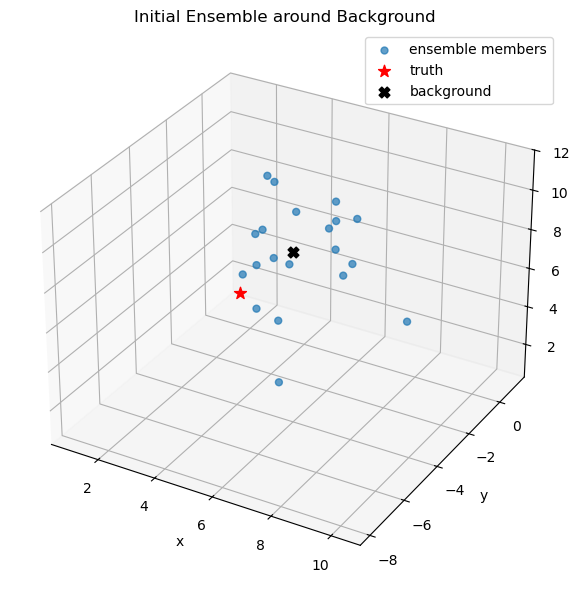

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_initial_ensemble.png


In [7]:
# 초기 앙상블을 3차원 phase space에서 본다.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ensemble0[:, 0], ensemble0[:, 1], ensemble0[:, 2],
    s=25, alpha=0.7, label="ensemble members",
)
ax.scatter(*x0_true, color="red", s=80, marker="*", label="truth")
ax.scatter(*x0_background, color="black", s=60, marker="X", label="background")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Ensemble around Background")
ax.legend()

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_initial_ensemble.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 7. forecast–analysis 사이클

EnKF는 두 단계를 반복한다.

1. **forecast 단계**: 각 멤버를 모델로 한 step 전진시킨다.
   $$\mathbf{x}_i^f = M(\mathbf{x}_i^a)$$
2. **analysis 단계**: 관측 시점이 되면 perturbed-observation EnKF로 모든 멤버를 갱신한다.

여기서는 02번의 관측 시점 루프 구조를 그대로 따른다.
관측 시점마다, 갱신 직전에 가벼운 **multiplicative inflation** 을 적용해 앙상블 spread가
너무 작아지는 것을 막는다.

아래 `run_enkf` 함수는 이 사이클 전체를 수행하고, 모든 시각의 앙상블을 저장해 반환한다.

In [8]:
def run_enkf(
    x0,
    observations,
    H,
    R,
    n_members,
    spread,
    inflation_factor=1.0,
    seed=seed,
):
    "EnKF forecast-analysis 사이클을 수행하고 전체 앙상블 history를 반환한다."
    state_dim = np.asarray(x0).shape[0]
    rng = np.random.default_rng(seed)

    ens = initialize_ensemble(
        x0=x0, ensemble_size=n_members, spread=spread, rng=rng
    )

    history = np.zeros((nsteps + 1, n_members, state_dim))
    history[0] = ens

    counter = 0
    for n in range(nsteps):
        # forecast 단계: 멤버별로 한 step 전진
        for j in range(n_members):
            ens[j] = euler_step(ens[j], dt, lorenz63_rhs)

        # analysis 단계
        if (n + 1) in obs_index_set:
            if inflation_factor != 1.0:
                ens = multiplicative_inflation(ens, inflation_factor)
            ens = stochastic_enkf_analysis(
                ensemble_f=ens,
                y=observations[counter],
                H=H,
                R=R,
                rng=rng,
            )
            counter += 1

        history[n + 1] = ens

    return history

In [9]:
inflation_factor = 1.05

enkf_history = run_enkf(
    x0=x0_background,
    observations=observations_all,
    H=H_all,
    R=R_all,
    n_members=N,
    spread=spread,
    inflation_factor=inflation_factor,
    seed=seed,
)

# 앙상블 평균, 표준편차
enkf_mean = enkf_history.mean(axis=1)
enkf_std = enkf_history.std(axis=1, ddof=1)

print("EnKF history shape:", enkf_history.shape)
print("EnKF mean RMSE     :", mean_rmse(enkf_mean, truth))
print("3D-Var mean RMSE   :", mean_rmse(da_3dvar_all, truth))
print("Free run mean RMSE :", mean_rmse(free_run, truth))

EnKF history shape: (6001, 20, 3)
EnKF mean RMSE     : 0.6278982110864668
3D-Var mean RMSE   : 1.4099328068522763
Free run mean RMSE : 7.16670764914493


## 8. 앙상블 평균과 spread 시각화

각 변수에 대해 다음을 함께 그린다.

- truth
- free run
- EnKF 앙상블 평균
- EnKF 앙상블 spread (평균 $\pm$ 표준편차 영역)

앙상블이 truth를 잘 추적한다면, 앙상블 평균이 truth에 가깝고 spread 영역이 truth를 감싸야 한다.

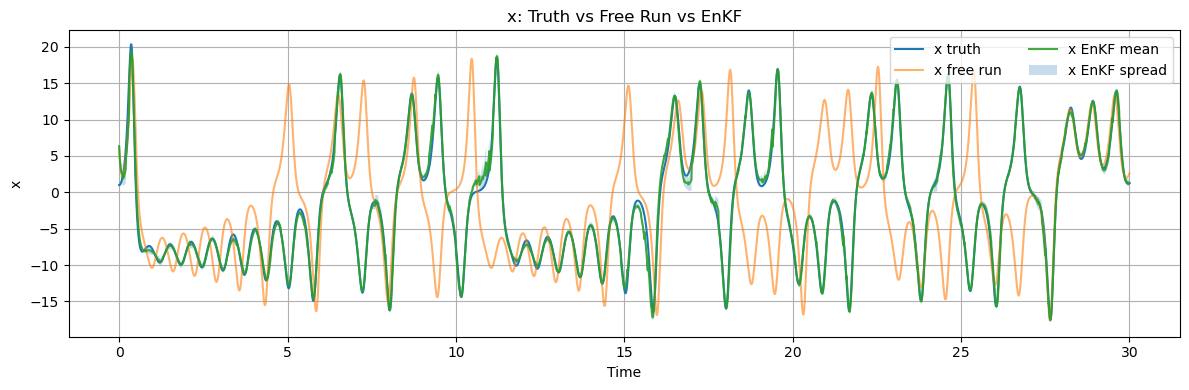

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_x_timeseries.png


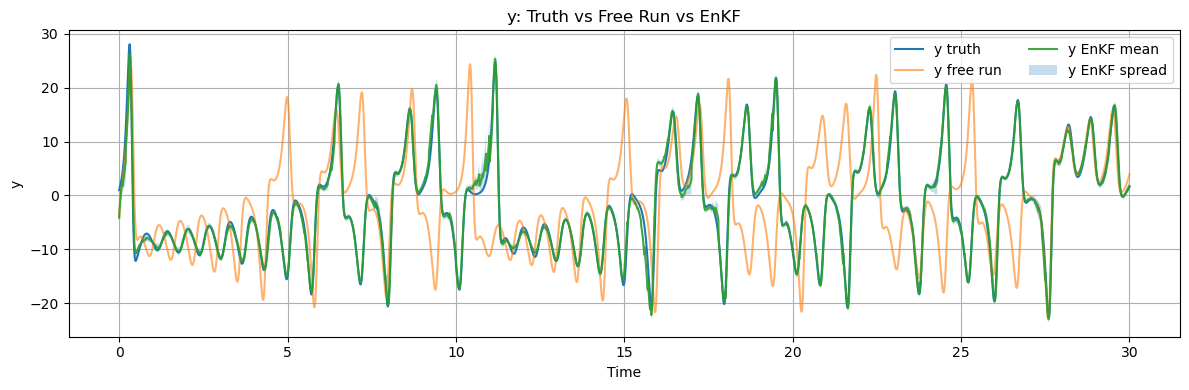

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_y_timeseries.png


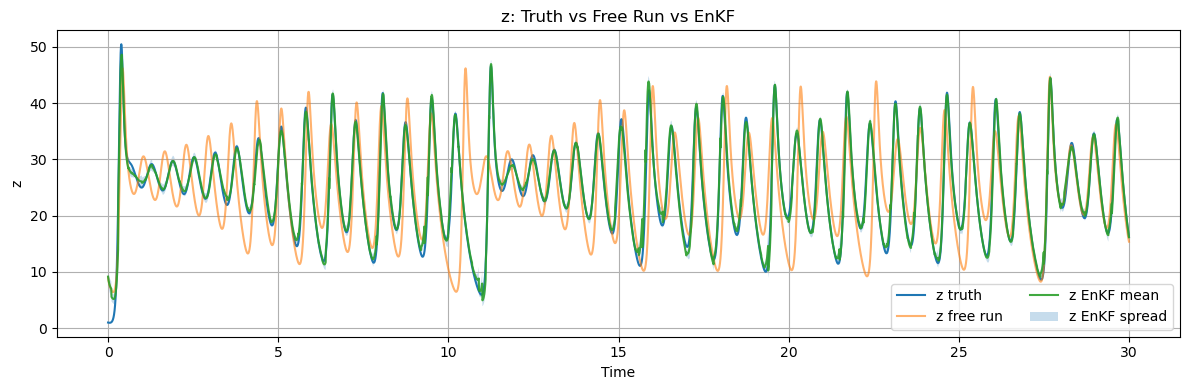

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_z_timeseries.png


In [10]:
for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(time, truth[:, i], label=f"{name} truth", linewidth=1.5)
    ax.plot(time, free_run[:, i], label=f"{name} free run", alpha=0.6)
    ax.plot(time, enkf_mean[:, i], label=f"{name} EnKF mean", alpha=0.9)
    ax.fill_between(
        time,
        enkf_mean[:, i] - enkf_std[:, i],
        enkf_mean[:, i] + enkf_std[:, i],
        alpha=0.25,
        label=f"{name} EnKF spread",
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"{name}: Truth vs Free Run vs EnKF")
    ax.legend(ncol=2)
    ax.grid(True)

    fig.tight_layout()
    fig_path = FIGURE_DIR / f"07_enkf_{name}_timeseries.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved figure:", fig_path)

## 9. RMSE 비교: free run vs 3D-Var vs EnKF

이번 실습의 핵심 비교이다.

- free run: 관측을 전혀 쓰지 않은 경우
- 3D-Var: 고정된 $B$ 를 쓴 경우 (02번)
- EnKF: 흐름 의존 $P^f$ 를 쓴 경우 (이번)

세 방법 모두 **같은 truth와 같은 관측**을 사용했으므로 직접 비교할 수 있다.

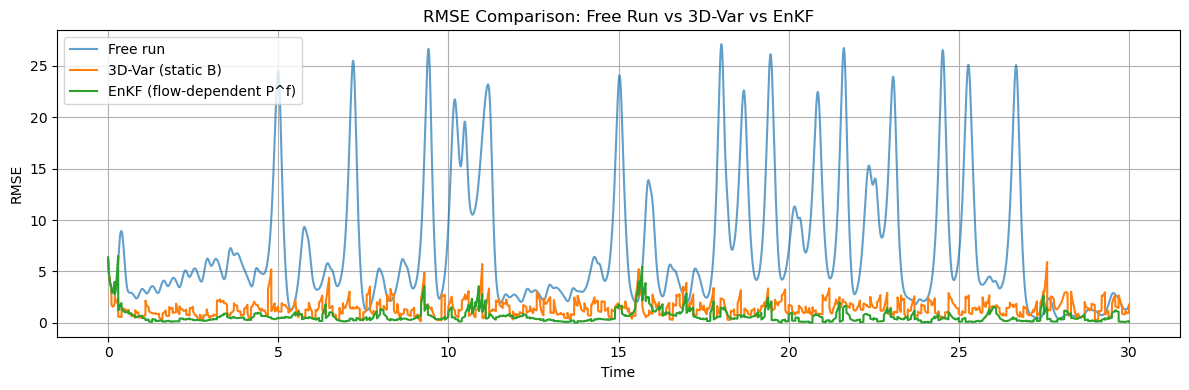

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_rmse_comparison.png
Mean RMSE
Free run : 7.16670764914493
3D-Var   : 1.4099328068522763
EnKF     : 0.6278982110864668


In [11]:
free_rmse = rmse_time_series(free_run, truth)
dvar_rmse = rmse_time_series(da_3dvar_all, truth)
enkf_rmse = rmse_time_series(enkf_mean, truth)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, free_rmse, label="Free run", alpha=0.7)
ax.plot(time, dvar_rmse, label="3D-Var (static B)")
ax.plot(time, enkf_rmse, label="EnKF (flow-dependent P^f)")

ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison: Free Run vs 3D-Var vs EnKF")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_rmse_comparison.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

print("Mean RMSE")
print("Free run :", mean_rmse(free_run, truth))
print("3D-Var   :", mean_rmse(da_3dvar_all, truth))
print("EnKF     :", mean_rmse(enkf_mean, truth))

## 10. 앙상블 spread와 실제 오차 비교

EnKF가 잘 작동하는지 보는 중요한 진단은 **앙상블 spread와 실제 오차가 비슷한가**이다.

- 앙상블 spread: 앙상블이 스스로 추정한 불확실성
  $$\text{spread}(t) = \sqrt{\frac{1}{3}\sum_{k} \text{Var}_k(t)}$$
- 실제 오차: 앙상블 평균과 truth의 RMSE

spread가 실제 오차보다 지나치게 작으면(과소확산, under-dispersion) 필터가 관측을 무시하게 된다.
inflation은 바로 이 spread를 키워 두 곡선을 비슷하게 맞추려는 장치이다.

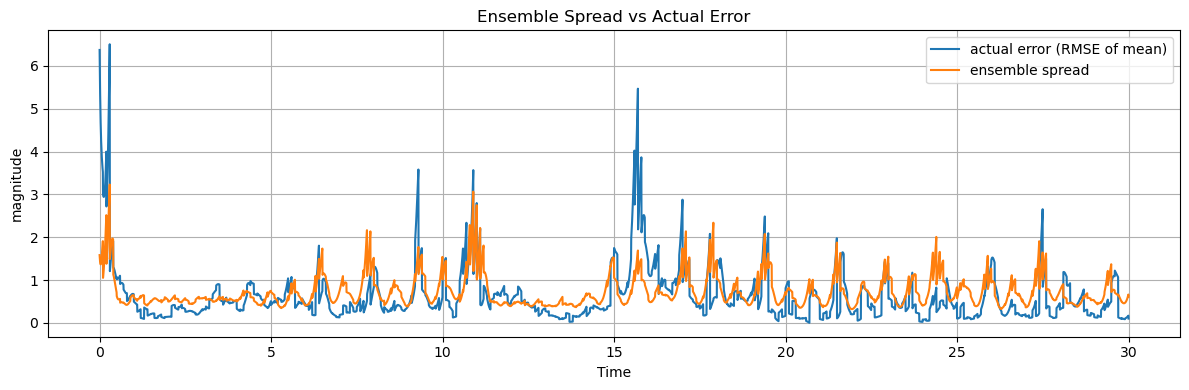

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_spread_vs_error.png
시간 평균 actual error : 0.6278982110864668
시간 평균 spread       : 0.7306060002593442


In [12]:
enkf_var = enkf_history.var(axis=1, ddof=1)         # (nsteps+1, 3)
enkf_spread = np.sqrt(enkf_var.mean(axis=1))         # (nsteps+1,)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, enkf_rmse, label="actual error (RMSE of mean)")
ax.plot(time, enkf_spread, label="ensemble spread")

ax.set_xlabel("Time")
ax.set_ylabel("magnitude")
ax.set_title("Ensemble Spread vs Actual Error")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_spread_vs_error.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

print("시간 평균 actual error :", float(enkf_rmse.mean()))
print("시간 평균 spread       :", float(enkf_spread.mean()))

## 11. 실험: `x`만 관측하는 경우

이번에는 `x`만 관측한다. 02번에서는 `x`만 관측할 때, $B$ 에 변수 간 covariance를 넣어야
(`correlated B`) 관측되지 않은 `y`, `z` 까지 보정되었다.

EnKF에서는 이런 covariance를 사람이 직접 넣어 줄 필요가 없다.
앙상블이 모델 역학을 따라 함께 전진하면서 변수 간 상관이 $P^f$ 안에 **자동으로** 들어오기 때문이다.

따라서 `x`만 관측해도 EnKF는 `y`, `z` 를 자연스럽게 보정할 수 있다.

In [13]:
# x만 관측
H_x = partial_observation_operator(observed_indices=[0], state_dim=3)
R_x = np.array([[obs_std**2]])

obs_x_path = ASSIM_DIR / "02_observations_xonly.npy"
if obs_x_path.exists():
    observations_x = np.load(obs_x_path)
    print("02번의 x-only 관측값을 불러왔다.")
else:
    print("x-only 관측값이 없어서 새로 생성한다.")
    rng_x = np.random.default_rng(seed)
    observations_x = generate_synthetic_observations(
        truth=truth, obs_indices=obs_indices, H=H_x, obs_std=obs_std, rng=rng_x
    )

# x만 관측하는 EnKF
enkf_x_history = run_enkf(
    x0=x0_background,
    observations=observations_x,
    H=H_x,
    R=R_x,
    n_members=N,
    spread=spread,
    inflation_factor=inflation_factor,
    seed=seed,
)
enkf_x_mean = enkf_x_history.mean(axis=1)

# 비교 대상: 02번의 x-only correlated B 3D-Var (없으면 즉석 계산)
dvar_x_corr_path = ASSIM_DIR / "02_3dvar_xobs_corrB_euler.npy"
if dvar_x_corr_path.exists():
    da_3dvar_x_corr = np.load(dvar_x_corr_path)
    print("02번의 x-only correlated-B 3D-Var 결과를 불러왔다.")
else:
    B_corr = np.array([[16.0, 8.0, 4.0], [8.0, 16.0, 6.0], [4.0, 6.0, 16.0]])
    da_3dvar_x_corr = run_3dvar(x0_background, observations_x, H_x, B_corr, R_x)

print("Mean RMSE (x only observed)")
print("3D-Var, correlated B :", mean_rmse(da_3dvar_x_corr, truth))
print("EnKF                 :", mean_rmse(enkf_x_mean, truth))

02번의 x-only 관측값을 불러왔다.


02번의 x-only correlated-B 3D-Var 결과를 불러왔다.
Mean RMSE (x only observed)
3D-Var, correlated B : 2.27272404052253
EnKF                 : 1.5726284914925353


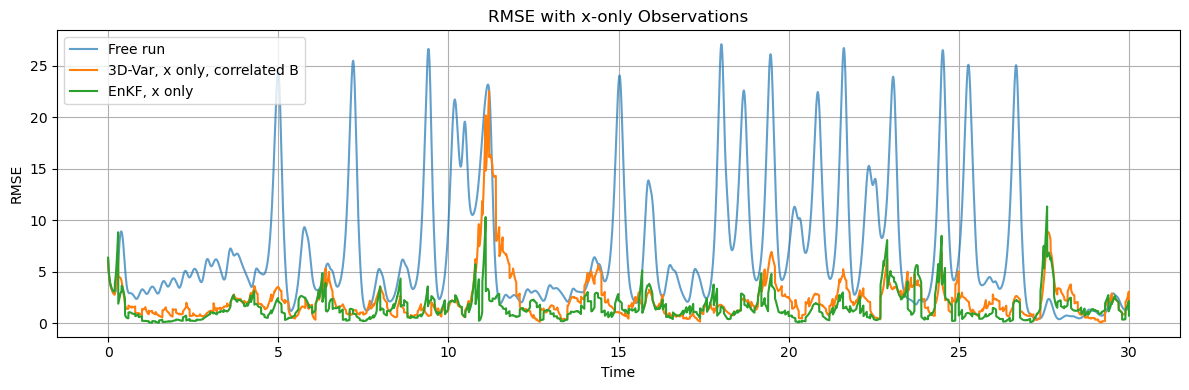

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_xonly_rmse.png


In [14]:
enkf_x_rmse = rmse_time_series(enkf_x_mean, truth)
dvar_x_rmse = rmse_time_series(da_3dvar_x_corr, truth)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, free_rmse, label="Free run", alpha=0.7)
ax.plot(time, dvar_x_rmse, label="3D-Var, x only, correlated B")
ax.plot(time, enkf_x_rmse, label="EnKF, x only")

ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE with x-only Observations")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_xonly_rmse.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

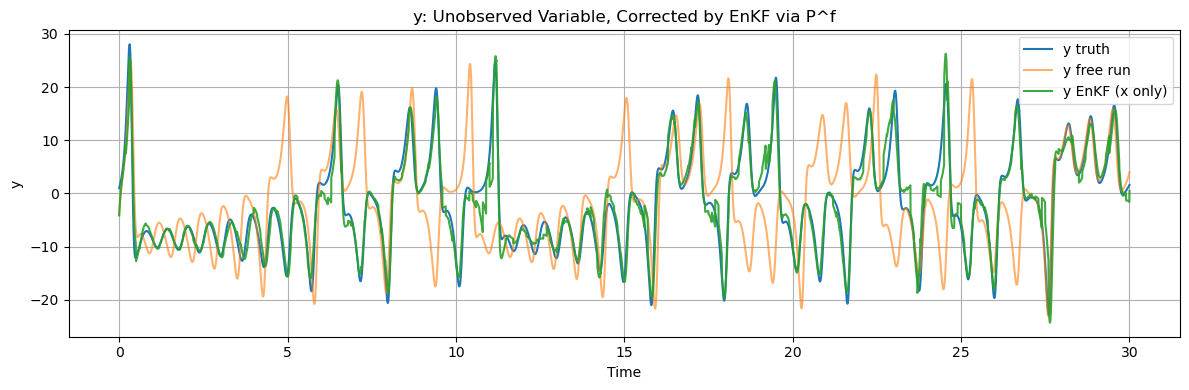

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_xonly_y.png


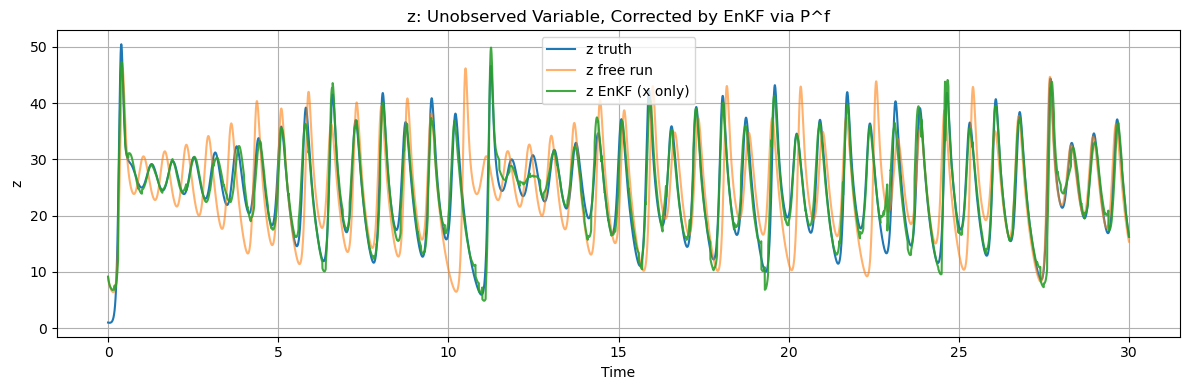

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_xonly_z.png


In [15]:
# y, z가 관측 없이도 보정되는지 직접 확인한다.
for i, name in zip([1, 2], ["y", "z"]):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time, truth[:, i], label=f"{name} truth", linewidth=1.5)
    ax.plot(time, free_run[:, i], label=f"{name} free run", alpha=0.6)
    ax.plot(time, enkf_x_mean[:, i], label=f"{name} EnKF (x only)", alpha=0.9)

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"{name}: Unobserved Variable, Corrected by EnKF via P^f")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()
    fig_path = FIGURE_DIR / f"07_enkf_xonly_{name}.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved figure:", fig_path)

## 12. 앙상블 크기의 영향

앙상블 크기 $N$ 이 작으면 $P^f$ 추정에 sampling error가 생긴다.
다만 Lorenz-63는 상태변수가 3개뿐인 저차원 계라서, $N$ 이 상태차원 정도만 되어도
정확도가 크게 변하지 않는다. 아래 결과에서도 $N$ 에 대한 의존성은 약하게 나타난다.
변수가 40개인 Lorenz-96(이후 실습)에서는 이 의존성이 훨씬 커진다는 점을 미리 기억해 두자.

N =   5 -> mean RMSE = 0.5790


N =  10 -> mean RMSE = 0.6265


N =  20 -> mean RMSE = 0.6279


N =  50 -> mean RMSE = 0.6108


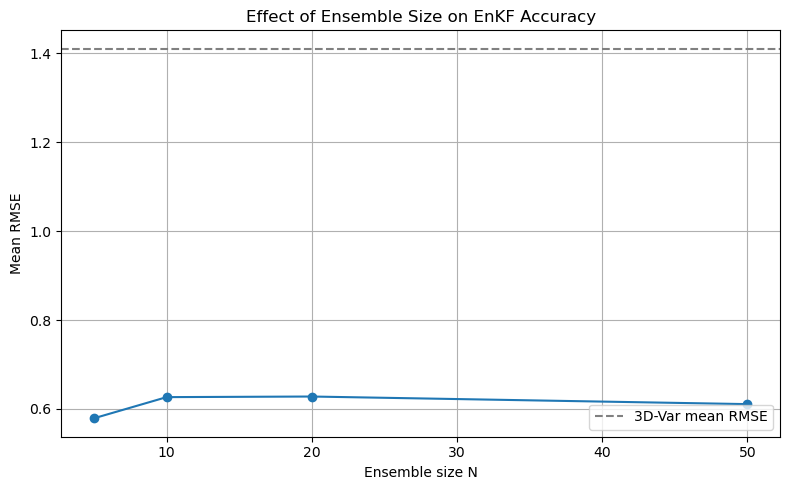

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_ensemble_size_rmse.png


In [16]:
ensemble_sizes = [5, 10, 20, 50]
size_rmse = {}

for n_members in ensemble_sizes:
    hist = run_enkf(
        x0=x0_background,
        observations=observations_all,
        H=H_all,
        R=R_all,
        n_members=n_members,
        spread=spread,
        inflation_factor=inflation_factor,
        seed=seed,
    )
    m = hist.mean(axis=1)
    size_rmse[n_members] = mean_rmse(m, truth)
    print(f"N = {n_members:3d} -> mean RMSE = {size_rmse[n_members]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(size_rmse.keys()), list(size_rmse.values()), marker="o")
ax.axhline(mean_rmse(da_3dvar_all, truth), linestyle="--", color="gray",
           label="3D-Var mean RMSE")

ax.set_xlabel("Ensemble size N")
ax.set_ylabel("Mean RMSE")
ax.set_title("Effect of Ensemble Size on EnKF Accuracy")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_ensemble_size_rmse.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 13. Inflation의 영향

10절에서 본 것처럼 앙상블 spread가 실제 오차보다 작아지면(과소확산) 필터가 관측을 무시한다.
**multiplicative inflation** 계수를 바꿔 가며 그 효과를 확인한다.

- `factor = 1.0`: inflation 없음
- `factor > 1.0`: 앙상블 perturbation을 키워 spread 보강

다만 이번 설정은 모든 변수를 자주 관측하므로 10절에서 이미 spread $\approx$ 실제 오차였다.
즉 과소확산이 심하지 않아, 여기서는 inflation이 RMSE를 더 낮추지 못하고 오히려
과하게 키우면 정확도가 나빠질 수 있다. inflation은 관측이 희소하거나 모델이 고차원이어서
spread가 과소평가되는 상황에서 진가를 발휘한다.

inflation factor = 1.00 -> mean RMSE = 0.5737


inflation factor = 1.05 -> mean RMSE = 0.6279


inflation factor = 1.10 -> mean RMSE = 0.6987


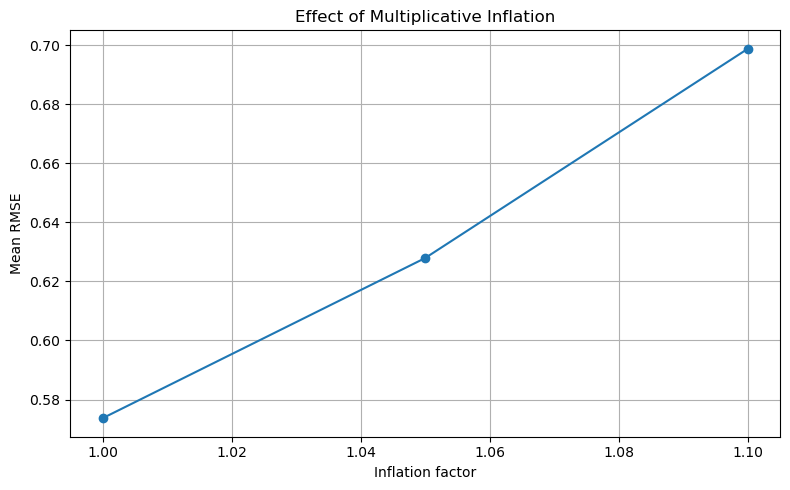

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/07_enkf_inflation_rmse.png


In [17]:
inflation_factors = [1.0, 1.05, 1.1]
inflation_rmse = {}

for factor in inflation_factors:
    hist = run_enkf(
        x0=x0_background,
        observations=observations_all,
        H=H_all,
        R=R_all,
        n_members=N,
        spread=spread,
        inflation_factor=factor,
        seed=seed,
    )
    m = hist.mean(axis=1)
    inflation_rmse[factor] = mean_rmse(m, truth)
    print(f"inflation factor = {factor:.2f} -> mean RMSE = {inflation_rmse[factor]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(inflation_rmse.keys()), list(inflation_rmse.values()), marker="o")

ax.set_xlabel("Inflation factor")
ax.set_ylabel("Mean RMSE")
ax.set_title("Effect of Multiplicative Inflation")
ax.grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "07_enkf_inflation_rmse.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 14. 결과 저장

In [18]:
np.save(ASSIM_DIR / "07_enkf_mean_allvars.npy", enkf_mean)
np.save(ASSIM_DIR / "07_enkf_std_allvars.npy", enkf_std)
np.save(ASSIM_DIR / "07_enkf_mean_xonly.npy", enkf_x_mean)

summary_path = ASSIM_DIR / "07_enkf_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Lorenz-63 Stochastic EnKF 실습 요약\n\n")
    f.write(f"dt: {dt}\n")
    f.write(f"tmax: {tmax}\n")
    f.write(f"obs_interval: {obs_interval}\n")
    f.write(f"obs_std: {obs_std}\n")
    f.write(f"ensemble size N: {N}\n")
    f.write(f"initial spread: {spread}\n")
    f.write(f"inflation factor: {inflation_factor}\n\n")
    f.write("Mean RMSE (all variables observed)\n")
    f.write(f"Free run : {mean_rmse(free_run, truth):.6f}\n")
    f.write(f"3D-Var   : {mean_rmse(da_3dvar_all, truth):.6f}\n")
    f.write(f"EnKF     : {mean_rmse(enkf_mean, truth):.6f}\n\n")
    f.write("Mean RMSE (x only observed)\n")
    f.write(f"3D-Var, correlated B : {mean_rmse(da_3dvar_x_corr, truth):.6f}\n")
    f.write(f"EnKF                 : {mean_rmse(enkf_x_mean, truth):.6f}\n")

print("Saved EnKF results to:", ASSIM_DIR)
print("Saved summary:", summary_path)

Saved EnKF results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation
Saved summary: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/07_enkf_summary.txt


## 15. 이번 실습 정리

이번 노트북에서는 Lorenz-63 모델에 stochastic EnKF를 적용했다.

확인한 내용은 다음과 같다.

1. EnKF는 앙상블의 퍼짐으로부터 흐름 의존 공분산 $P^f$ 를 추정한다.
2. 3D-Var의 고정된 $B$ 와 달리, $P^f$ 는 매 순간 모델 상태에 맞게 바뀐다.
3. 같은 truth와 관측에 대해 EnKF는 free run보다 훨씬 정확하며, 3D-Var와 견줄 만하거나 더 낫다.
4. `x`만 관측해도 $P^f$ 안의 변수 간 상관 덕분에 `y`, `z` 가 자동으로 보정된다.
   (3D-Var에서는 이를 위해 correlated $B$ 를 사람이 직접 설계해야 했다.)
5. Lorenz-63는 저차원이라 앙상블 크기에 둔감했지만, 일반적으로 앙상블이 너무 작으면
   sampling error로 $P^f$ 추정이 나빠진다 (고차원 Lorenz-96에서 뚜렷해진다).
6. 이번 설정에서는 spread가 실제 오차와 이미 비슷해(10절) inflation이 RMSE를 더 낮추지 못했다.
   inflation은 spread가 과소평가되는 상황(희소 관측·고차원)에서 진가를 발휘한다.

이번 실습의 핵심 식은 다음이다.

$$
P^f = \frac{1}{N-1}\sum_{i=1}^{N}\mathbf{x}'_i (\mathbf{x}'_i)^T,
\qquad
\mathbf{x}_i^a = \mathbf{x}_i^f + K(\mathbf{y} + \boldsymbol{\epsilon}_i - H\mathbf{x}_i^f)
$$

다음 실습에서는 같은 Lorenz-63에서 앙상블을 적분하지 않고, 긴 free run의 climatology로 background covariance를 고정하는 EnOI(Ensemble Optimal Interpolation)를 살펴본다.
이는 EnKF의 공분산 추정과 3D-Var의 저렴함을 절충한 방법이다.

In [19]:
print("일곱 번째 실습 완료")
print("다음 실습: 08_lorenz63_enoi_euler.ipynb (EnOI, climatological B)")

일곱 번째 실습 완료
다음 실습: 08_lorenz63_enoi_euler.ipynb (EnOI, climatological B)
